In [1]:
import pandas as pd
import numpy as np
from utils import preprocess
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("data/3274-Device-Data-Fix.csv")
df = preprocess.get_clean_df(df)

                 date  irrigation_volume_0  irrigation_volume_accumulated_0  \
0 2024-04-07 22:30:00                  NaN                              NaN   
1 2024-04-07 23:00:00                  0.0                              0.0   
2 2024-04-07 23:30:00                  0.0                              0.0   
3 2024-04-08 00:00:00                  0.0                              0.0   
4 2024-04-08 00:30:00                  0.0                              0.0   

   soil_moisture_20  soil_moisture_40  soil_moisture_60  
0               NaN               NaN             0.208  
1             0.237             0.334             0.208  
2             0.237             0.334             0.208  
3             0.237             0.333             0.208  
4             0.237             0.333             0.208  


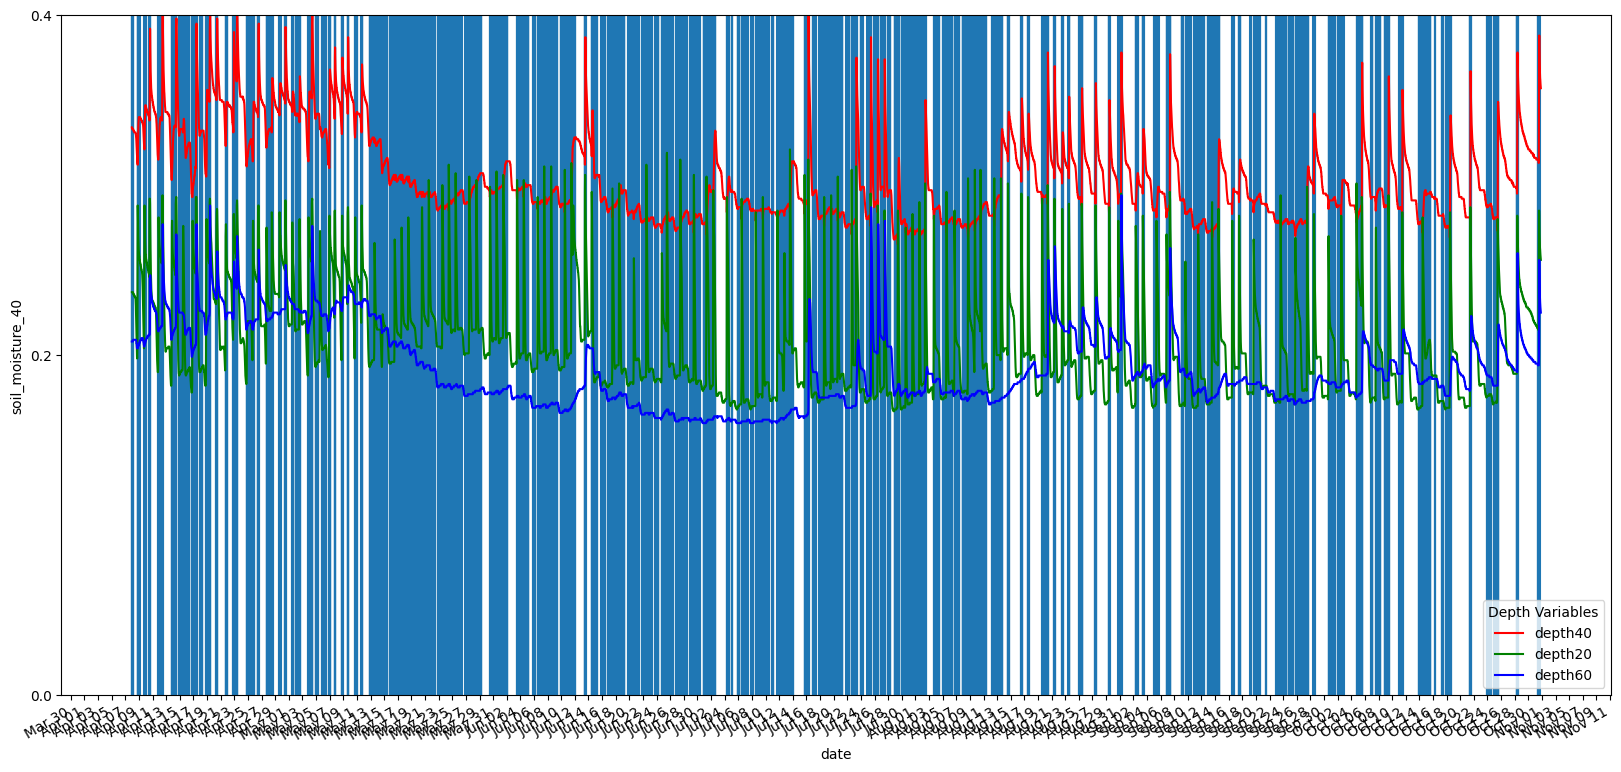

In [3]:
start_date = pd.to_datetime("2024-04-01")
end_date   = pd.to_datetime("2024-10-10")
df_constricted = df[(df["date"].dt.month >= start_date.month) & (df["date"].dt.month <= end_date.month) & (df["date"].dt.year <= end_date.year)].copy()
# df_constricted = df[(df["date"] >= start_date) & (df["date"] <= end_date) & (df["date"].dt.year <= end_date.year)].copy()
print(df_constricted.head())
orig_values = df_constricted["soil_moisture_40"].to_numpy()
values = gaussian_filter1d(orig_values, sigma=2)
df_constricted["soil_moisture_40"] = values

df_constricted['prev_value'] = df_constricted['soil_moisture_40'].shift(1)
df_constricted['difference'] = df_constricted['soil_moisture_40'] - df_constricted['prev_value']

df_constricted["peak"] = False
df_constricted["steps_from_peak"] = 0

GRAD_THRESH_HIGH = 0.001

current_steps = -1
up = False

for row in df_constricted.iloc[1:].itertuples(index=True):
    dx = abs(row.difference)
    down = row.difference <= 0
    current_steps += 1
    
    # if row.irrigation_volume_0 != 0:
    #     up = True
    #     df_constricted.loc[row.Index, "peak"] = True
    #     current_steps = -1
    #     counter = 0
    # elif not up:
    #     df_constricted.loc[row.Index, "steps_from_peak"] = current_steps
    # else:
    #     counter += 1
    #     if counter > 2:
    #         counter = 0
    #         up = False
    
    if not down:
        df_constricted.loc[row.Index, "peak"] = True
        current_steps = -1
    else:
        df_constricted.loc[row.Index, "steps_from_peak"] = current_steps


df_constricted["soil_moisture_40"] = orig_values

plt.figure(figsize=(20, 10))

for row in df_constricted.itertuples(index=True):
    if row.peak:
        plt.axvline(df_constricted.loc[row.Index, "date"])
sns.lineplot(df_constricted, x="date", y="soil_moisture_40", label="depth40", color="red")
sns.lineplot(df_constricted, x="date", y="soil_moisture_20", label="depth20", color="green")
sns.lineplot(df_constricted, x="date", y="soil_moisture_60", label="depth60", color="blue")
plt.legend(title="Depth Variables")
plt.ylim(0, 0.40)
plt.yticks([0, 0.20, 0.40])
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()  # rotate labels for clarity
plt.show()

In [4]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

In [5]:
df_decay = df_constricted[~df_constricted["peak"]]
df_decay = df_decay.drop(columns=["irrigation_volume_0", "irrigation_volume_accumulated_0", "prev_value", "difference", "peak"])[1:].reset_index(drop=True)
df_decay["hour"] = df_decay["date"].dt.hour
df_decay["season"] = df_decay["date"].dt.month.apply(get_season)
df_decay = pd.get_dummies(df_decay, columns=['season'])
df_decay['soil_moisture_next'] = df_decay['soil_moisture_40'].shift(-1)
df_decay['next_steps'] = df_decay['steps_from_peak'].shift(-1)
df_decay = df_decay[df_decay["next_steps"] != 0]
df_decay = df_decay.drop(columns=["date", "soil_moisture_20", "soil_moisture_60", "next_steps"])[:-1]
df_decay.head()

,soil_moisture_40,steps_from_peak,hour,season_autumn,season_spring,season_summer,soil_moisture_next
0,0.333,0,3,False,True,False,0.332
1,0.332,1,4,False,True,False,0.332
2,0.332,2,4,False,True,False,0.332
3,0.332,3,5,False,True,False,0.332
4,0.332,4,5,False,True,False,0.332


In [6]:
X_train = df_decay[["soil_moisture_40", "steps_from_peak", "hour", "season_autumn", "season_spring", "season_summer"]].copy()
X_train["hour"] = X_train["hour"] / 24
print(X_train.head())

y_train = df_decay["soil_moisture_next"]
print(y_train)

   soil_moisture_40  steps_from_peak      hour  season_autumn  season_spring  \
0             0.333                0  0.125000          False           True   
1             0.332                1  0.166667          False           True   
2             0.332                2  0.166667          False           True   
3             0.332                3  0.208333          False           True   
4             0.332                4  0.208333          False           True   

   season_summer  
0          False  
1          False  
2          False  
3          False  
4          False  
0       0.332
1       0.332
2       0.332
3       0.332
4       0.332
        ...  
6051    0.362
6052    0.360
6053    0.359
6054    0.358
6055    0.357
Name: soil_moisture_next, Length: 5821, dtype: float64


In [7]:
from utils.models import *
from utils.preprocess import *
import xgboost as xgb
from utils.eval import *

ESTIMATORS = 700
DEPTH = 3
DIFF = True

X_new = X_train.copy()


X_new["t0"] = X_new["soil_moisture_40"]
X_new["t1"] = X_new["soil_moisture_40"].shift(-1)
X_new["t2"] = X_new["soil_moisture_40"].shift(-2)
X_new["res"] = X_new["soil_moisture_40"].shift(-3)
X_new["season_autumn"] = X_new["season_autumn"].shift(-3).astype(bool)
X_new["season_summer"] = X_new["season_summer"].shift(-3).astype(bool)
X_new["season_spring"] = X_new["season_spring"].shift(-3).astype(bool)
X_new["next_step"] = X_new["steps_from_peak"].shift(-3)
X_new["hour"] = X_new["hour"].shift(-2)
X_new["hour_s"] = np.sin(2 * np.pi * X_new["hour"])
X_new["hour_c"] = np.cos(2 * np.pi * X_new["hour"])

condition = X_new["next_step"] >= 3

condition_full = ~X_new["t2"].isna() & condition

X_new = X_new.loc[condition_full]

y_new = X_new["res"] - X_new["t2"]
X_new = X_new[["t0", "t1", "t2", "next_step", "hour_s", "hour_c", "season_autumn", "season_spring", "season_summer"]]
X_new.head()

,t0,t1,t2,next_step,hour_s,hour_c,season_autumn,season_spring,season_summer
0,0.333,0.332,0.332,3.0,0.866025,5.000000e-01,False,True,False
1,0.332,0.332,0.332,4.0,0.965926,2.588190e-01,False,True,False
2,0.332,0.332,0.332,5.0,0.965926,2.588190e-01,False,True,False
3,0.332,0.332,0.332,6.0,1.000000,6.123234e-17,False,True,False
4,0.332,0.332,0.332,7.0,1.000000,6.123234e-17,False,True,False


In [8]:
y_new

0       0.000
1       0.000
2       0.000
3       0.000
4      -0.001
        ...  
6048   -0.002
6049   -0.001
6050   -0.002
6051   -0.001
6052   -0.001
Length: 5133, dtype: float64

In [9]:
from sklearn.metrics import mean_absolute_error

model = get_XGBoost(X_new, y_new)

dtrain = xgb.DMatrix(X_new, label=y_new)

pred = model.predict(dtrain)

X_new_pred = merge_diff_with_prob(X_new, pred, p=0.3)

model = get_XGBoost(X_new_pred, y_new)

y_pred = model.predict(dtrain)
residuals = (y_new + X_new["t2"]) - (y_pred + X_new["t2"])
deviation = residuals.std()

[0]	train-rmse:0.00088	eval-rmse:0.00086
[1]	train-rmse:0.00086	eval-rmse:0.00084
[2]	train-rmse:0.00085	eval-rmse:0.00082
[3]	train-rmse:0.00083	eval-rmse:0.00081
[4]	train-rmse:0.00082	eval-rmse:0.00079
[5]	train-rmse:0.00080	eval-rmse:0.00078
[6]	train-rmse:0.00079	eval-rmse:0.00077
[7]	train-rmse:0.00078	eval-rmse:0.00076
[8]	train-rmse:0.00077	eval-rmse:0.00075
[9]	train-rmse:0.00076	eval-rmse:0.00074
[10]	train-rmse:0.00075	eval-rmse:0.00073
[11]	train-rmse:0.00074	eval-rmse:0.00072
[12]	train-rmse:0.00073	eval-rmse:0.00071
[13]	train-rmse:0.00072	eval-rmse:0.00070
[14]	train-rmse:0.00072	eval-rmse:0.00070
[15]	train-rmse:0.00071	eval-rmse:0.00069
[16]	train-rmse:0.00070	eval-rmse:0.00069
[17]	train-rmse:0.00070	eval-rmse:0.00068
[18]	train-rmse:0.00069	eval-rmse:0.00068
[19]	train-rmse:0.00069	eval-rmse:0.00067
[20]	train-rmse:0.00068	eval-rmse:0.00066
[21]	train-rmse:0.00068	eval-rmse:0.00066
[22]	train-rmse:0.00068	eval-rmse:0.00066
[23]	train-rmse:0.00067	eval-rmse:0.00065
[2

[0.354 0.353 0.352]
103
103
103


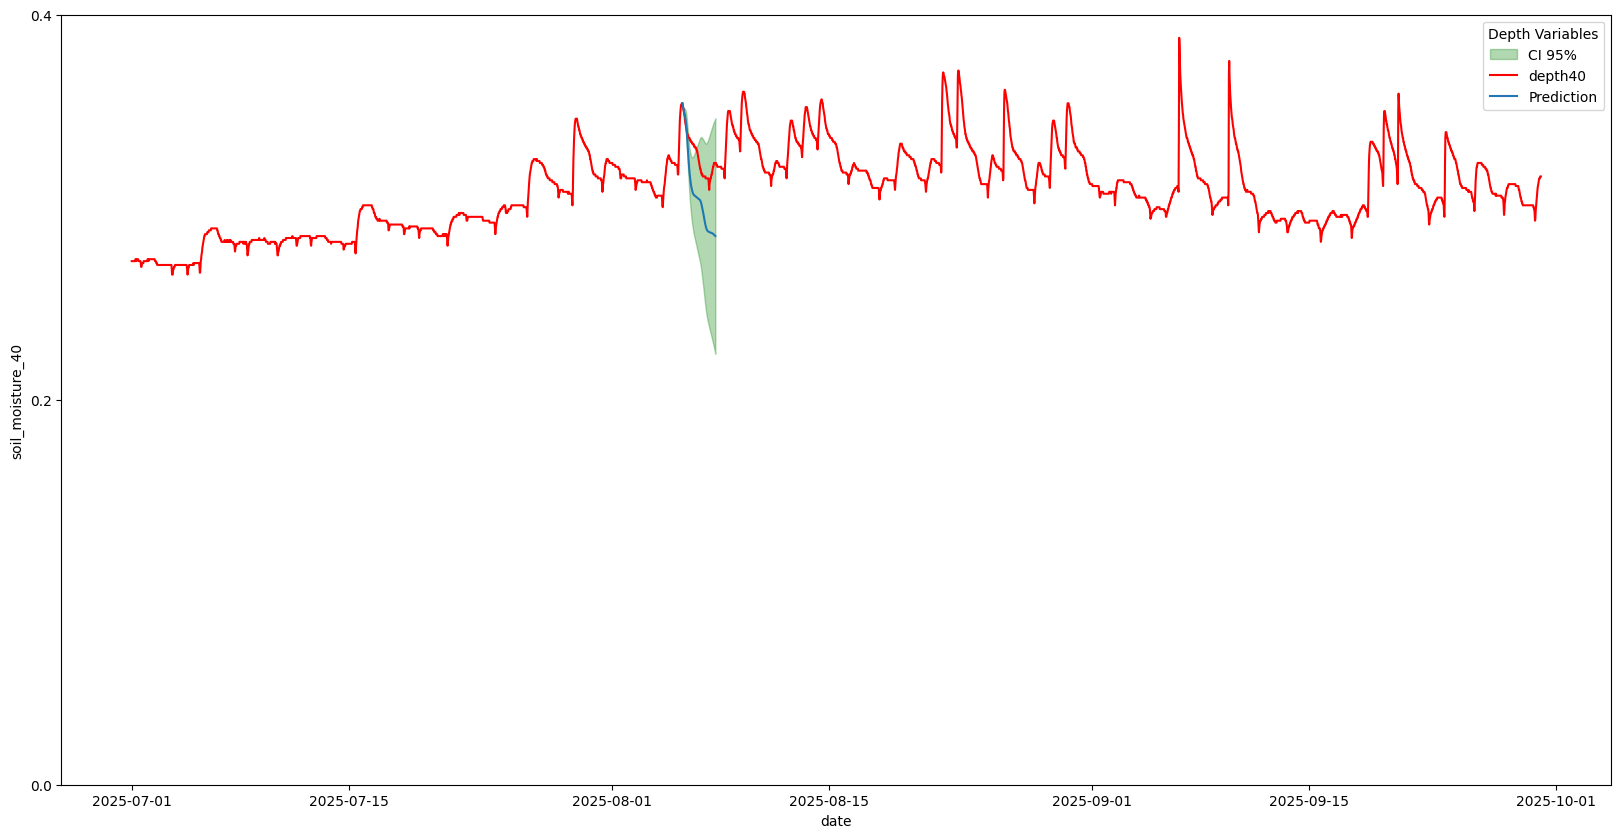

In [47]:
format_func = format_XGBoost

start_date = pd.to_datetime("2025-07-01")
end_date   = pd.to_datetime("2025-09-30")
df_pred = df[(df["date"]>= start_date) & (df["date"] <= end_date)].copy()

current_value = df.loc[df["date"] >= pd.to_datetime("2025-08-05 13:30:00")]
current_date = pd.to_datetime("2025-08-05 13:30:00")
current_hour = 8

print(current_value.head(3)["soil_moisture_40"].values)

steps = 100

input_names = ["soil_moisture_40", "steps_from_peak", "hour"]

predictions = current_value.head(3)["soil_moisture_40"].values

for i in range(steps):
    hour_s = np.sin(2 * np.pi * current_hour / 24)
    hour_c = np.cos(2 * np.pi * current_hour / 24)
    input_vec = np.concat([predictions[-3:], [i+3, hour_s, hour_c, False, False, True]]).reshape(1, -1)
    pred = model.predict(format_func(input_vec))
    current_hour = (current_hour + i%2)%24
    predictions = np.append(predictions, pred[0] + predictions[-1])

deviations = [0, 0, 0]
values = [c for c in predictions]
times = np.array([current_date + pd.Timedelta(hours=i/2) for i in range(steps + 3)])
deviations = np.array(deviations + [i * deviation for i in range(1, steps+1)])
print(len(deviations))
print(len(times))
print(len(values))

plt.figure(figsize=(20, 10))
plt.fill_between(times, values - deviations, values + deviations, alpha=0.3, color='green', label="CI 95%")
sns.lineplot(df_pred, x="date", y="soil_moisture_40", label="depth40", color="red")
sns.lineplot(x=times, y=values, label="Prediction")
plt.legend(title="Depth Variables")
plt.ylim(0, 0.40)
plt.yticks([0, 0.20, 0.40])
plt.show()